# 8. Volumetric uncertainty with Monte Carlo simulation

        Reproducible sampling propagates uncertain area, pay, porosity, saturation, and formation
        volume factor through the OOIP equation. Distribution choices remain engineering assumptions.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))


In [2]:
from petroleum_python.petrophysics import oil_in_place_stb
rng = np.random.default_rng(42)
n = 20_000
area_acres = rng.triangular(600, 800, 1100, n)
net_pay_ft = np.clip(rng.normal(45, 7, n), 20, 75)
porosity_fraction = np.clip(rng.normal(0.20, 0.025, n), 0.10, 0.30)
water_saturation = np.clip(rng.normal(0.28, 0.04, n), 0.12, 0.50)
bo_rb_stb = np.clip(rng.normal(1.24, 0.045, n), 1.05, 1.45)
ooip_mmstb = np.array([
    oil_in_place_stb(a, h, phi, sw, bo) for a, h, phi, sw, bo in
    zip(area_acres, net_pay_ft, porosity_fraction, water_saturation, bo_rb_stb)
]) / 1e6
p90, p50, p10 = np.percentile(ooip_mmstb, [10, 50, 90])
print(f"OOIP P90={p90:.1f}, P50={p50:.1f}, P10={p10:.1f} MMstb")


OOIP P90=23.7, P50=33.1, P10=45.0 MMstb


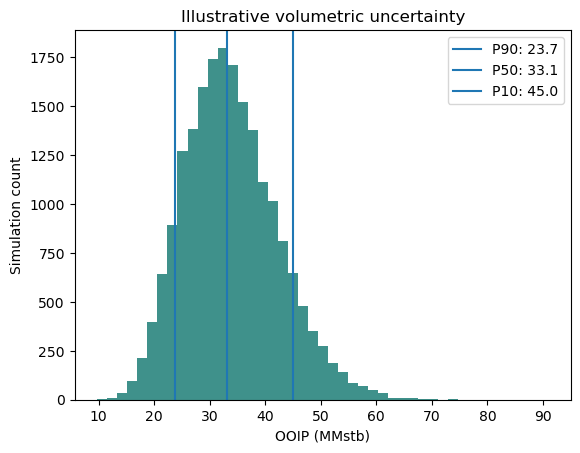

In [3]:
plt.hist(ooip_mmstb, bins=45, color="#0f766e", alpha=0.8)
for value, label in [(p90, "P90"), (p50, "P50"), (p10, "P10")]:
    plt.axvline(value, label=f"{label}: {value:.1f}")
plt.xlabel("OOIP (MMstb)")
plt.ylabel("Simulation count")
plt.title("Illustrative volumetric uncertainty")
plt.legend()
plt.show()


## Interpretation

        For a positive volume distribution, P90 is the low case (90 percent probability of
        exceeding it), while P10 is the high case. Correlation between inputs is omitted here and
        should be considered in a real uncertainty model.